# 1. Imports and Reads

In [6]:
import json
import pickle
from src.utils.feature_importance_utils import *
from src.visualization.plot_utils import *
from src.utils.results_io import ResultsIO
from src.utils.notation_utils import feature_to_physics_notation
from sklearn.metrics import mean_absolute_error, r2_score

In [7]:
np.random.seed(42)

BASE_PATH = '../../Zenodo/data/2024-05-01_2024-05-14/'
BASE_DATA_PATH = '../../Zenodo/data/2024-05-01_2024-05-14/processed'
INPUT_CONFIG_PATH = '../../Zenodo/data/2024-05-01_2024-05-14/configs/POD/config_pretty.json'
RESULTS_BASE_PATH = "../../Zenodo/results/2024-05-01_2024-05-14/"
RESULTS_SUMMARY = "summary/"

# ignore the misinforming name (real units are m/day)
target = 'Orbital Decay (m) - without maneuvers'

satellite_configuration = json.load(open(INPUT_CONFIG_PATH))
satellites = list(satellite_configuration.keys())
icme_durations = json.load(open(os.path.join(BASE_PATH, 'CMEs', 'icme_durations_all_catalogs.json'), 'r'))

In [8]:
results_summaries = os.listdir(os.path.join(RESULTS_BASE_PATH, RESULTS_SUMMARY))

pattern = re.compile(r'_(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}).pkl$')
most_recent_result = max([f for f in results_summaries if f.endswith('.pkl')], key=lambda f: os.path.getctime(os.path.join(RESULTS_BASE_PATH, RESULTS_SUMMARY, f)))
most_recent_timestamp = most_recent_result.split('_', 4)[-1].replace('.pkl', '')

scores_and_coef_dfs = pickle.load(open(os.path.join(RESULTS_BASE_PATH, RESULTS_SUMMARY, most_recent_result), 'rb'))
most_recent_grid_config = json.load(open(os.path.join(RESULTS_BASE_PATH, RESULTS_SUMMARY, f'reference_grid_config_{most_recent_timestamp}.json'), 'r'))
target_lags = most_recent_grid_config['target_lags_minutes']

# 2. Inspect grid search results

Read the grid search results for all satellites and filter out the best models based on cross-validation MAE. Note that some models may have failed to converge, which is indicated in the 'notes' column of the results dataframe.

In [9]:
grid_config_path = most_recent_grid_config['grid_config_path'].replace('data', '../../Zenodo/data')
grid_path = grid_config_path.replace('configs/', 'outputs/').replace('.json', '_grid_all.csv').replace('grid_config_', '')
df = pd.read_parquet(grid_path)
df.head()

,satellite,n_splits,k,alpha_range,tol,best_alpha,n_iterations,mean_cv_MAE,mean_cv_r2,std_cv_r2,...,train_days,test_days,offset,whitelisted_features,selected_features,detrend,use_time_feature,input_lags,max_iter,notes
0,GFOC_RDCDFI,5,100,"np.logspace(-1, -0.5228787452803376, 1000)",0.0001,0.299670,915.0,5.660836,-4.002086,3.471594,...,6.0,7.0,0,"[F10.7 (LASP)_1, F10.7 (LASP)_5, F10.7 (LASP)_...","[AsyH (Omni), ap (LASP), |avg B|, Flow Speed (...",True,True,"[1, 5, 10, 15, 30, 45, 60, 90, 120, 150, 180]",1500,Model converged successfully.
1,GFOC_RDCDFI,5,90,"np.logspace(-1, -0.5228787452803376, 1000)",0.0001,0.239976,1101.0,6.049480,-4.496684,3.330174,...,6.0,7.0,0,"[F10.7 (LASP)_1, F10.7 (LASP)_5, F10.7 (LASP)_...","[AsyH (Omni), ap (LASP), |avg B|, Flow Speed (...",True,True,"[1, 5, 10, 15, 30, 45, 60, 90, 120, 150, 180]",1500,Model converged successfully.
2,GFOC_RDCDFI,5,80,"np.logspace(-1, -0.5228787452803376, 1000)",0.0001,0.246937,937.0,6.183595,-4.581161,3.396269,...,6.0,7.0,0,"[F10.7 (LASP)_1, F10.7 (LASP)_5, F10.7 (LASP)_...","[AsyH (Omni), ap (LASP), |avg B|, Flow Speed (...",True,True,"[1, 5, 10, 15, 30, 45, 60, 90, 120, 150, 180]",1500,Model converged successfully.
3,GFOC_RDCDFI,5,150,"np.logspace(-1, -0.5228787452803376, 1000)",0.0001,0.181293,1006.0,7.238771,-4.977983,2.043526,...,6.0,7.0,0,"[F10.7 (LASP)_1, F10.7 (LASP)_5, F10.7 (LASP)_...","[SymH (Omni), AsyD (Omni), AsyH (Omni), ap (LA...",True,True,"[1, 5, 10, 15, 30, 45, 60, 90, 120, 150, 180]",1500,Model converged successfully.
4,GFOC_RDCDFI,5,300,"np.logspace(-1, -0.5228787452803376, 1000)",0.0001,0.100110,1008.0,7.474335,-5.476607,3.764094,...,6.0,7.0,0,"[F10.7 (LASP)_1, F10.7 (LASP)_5, F10.7 (LASP)_...","[SymD (Omni), SymH (Omni), AsyD (Omni), AsyH (...",True,True,"[1, 5, 10, 15, 30, 45, 60, 90, 120, 150, 180]",1500,Model converged successfully.


In [10]:

df = df[df['notes'].str.contains("success")].sort_values('mean_cv_MAE')
res = df.groupby('satellite').apply(lambda x: x.loc[x['mean_cv_MAE'].idxmin()])[['satellite', 'mean_cv_MAE', 'best_alpha', 'test_r2','selected_features', 'k', 'n_iterations']].reset_index(drop=True)
res['has_diff'] = res['selected_features'].apply(lambda x: any(['diff' in feat for feat in x]))
res.drop('selected_features', axis=1, inplace=True)
res

,satellite,mean_cv_MAE,best_alpha,test_r2,k,n_iterations,has_diff
0,GFOC_RDCDFI,5.660836,0.299670,0.575027,100,915.0,False
1,GFOD_RDDDFI,5.571723,0.299670,0.575587,100,830.0,False
2,S1A_RDAMFI24,2.007202,0.072587,-0.157753,40,203.0,False
3,S2A_RDAZFI24,2.192755,0.108359,-0.407513,100,278.0,False
4,S2B_RDAFFI24,2.538371,0.028871,-2.494086,60,663.0,False
5,S3A_RDAEFI24,2.141365,0.081454,0.241122,300,387.0,True
6,S3B_RDAEFI24,1.985389,0.044530,0.322866,40,289.0,False
7,S6A_RDAFFI24,4.156406,0.225892,-6.122077,150,202.0,False
8,SWMA_RDAWFI24,7.069833,0.235273,0.629317,70,639.0,False
9,SWMB_RDBWFI24,4.019399,0.287405,0.088805,80,467.0,False


# 3. Model results for best-performing models during CV per satellite

In [11]:
scores_table = []
for sat in satellites:

    io = ResultsIO(
        results_base_path=RESULTS_BASE_PATH,
        satellite=sat,
        most_recent_timestamp=most_recent_timestamp,
        target=most_recent_grid_config['target'],
        score_type='no_val'
    )
    X_train, y_train, y_train_pred = io.read(mode='train')
    X_test, y_test, y_pred = io.read(mode='test')

    for X, y, y_pred in [(X_train, y_train, y_train_pred), (X_test, y_test, y_pred)]:
        mae = mean_absolute_error(y, y_pred['y_pred'])
        r2 = r2_score(y, y_pred['y_pred'])
        r2_adjusted = 1 - (((1 - r2) * (len(y) - 1)) / (len(y) - X.shape[1] - 1))
        peak_error = abs(y[target].max() - y_pred['y_pred'].max())
        row = {
            'Satellite': satellite_configuration[sat]['name'],
            'MAE': f"{mae:.2f}",
            '$\overline{R}^2$': f"{r2_adjusted:.2f}",
            'Dataset' : 'Train' if X is X_train else 'Test',
            'Peak AE': f"{peak_error:.2f}",
            'Altitude': satellite_configuration[sat]["altitude"]
        }
        scores_table.append(row)
    # print(f"Satellite: {satellite_configuration[sat]['name']}; lead time: {target_lags[satellites.index(sat)]} minutes")

    scores_table.append({
        'Satellite': satellite_configuration[sat]['name'],
        'MAE': f"{res[res['satellite'] == sat]['mean_cv_MAE'].values[0]:.2f}",
        'R2 adjusted': 'N/A',
        'Peak AE': 'N/A',
        'Dataset' : 'Val (CV)',
        'Altitude': satellite_configuration[sat]["altitude"]
    })

to_drop = [
    ('R2 adjusted', 'Val (CV)'),
    ('Peak AE', 'Train'),
    ('Peak AE', 'Val (CV)')
]

scores_df = (
    pd.DataFrame(scores_table)
      .assign(Dataset=lambda d: pd.Categorical(
          d['Dataset'],
          categories=['Train', 'Val (CV)', 'Test'],
          ordered=True
      ))
      .pivot_table(index='Satellite',
                   columns='Dataset',
                   values=['$\overline{R}^2$', 'MAE', 'Peak AE'],
                   aggfunc='first')
      .drop(columns=to_drop, errors='ignore')
)

altitudes = pd.DataFrame(scores_table).drop_duplicates('Satellite').set_index('Satellite')['Altitude']
scores_df['Altitude'] = altitudes
scores_df = scores_df.sort_values('Altitude')
scores_df.drop('Altitude', axis=1, inplace=True)

print(scores_df.to_latex(float_format='{:.2f}'.format))

\begin{tabular}{lllllll}
\toprule
 & \multicolumn{2}{r}{$\overline{R}^2$} & \multicolumn{3}{r}{MAE} & Peak AE \\
Dataset & Train & Test & Train & Val (CV) & Test & Test \\
Satellite &  &  &  &  &  &  \\
\midrule
Swarm A & 0.84 & 0.63 & 2.80 & 7.07 & 17.55 & 0.03 \\
Swarm C & 0.80 & 0.59 & 3.04 & 6.24 & 17.38 & 37.90 \\
GRACE-FO C & 0.77 & 0.57 & 2.74 & 5.66 & 12.50 & 5.98 \\
GRACE-FO D & 0.77 & 0.57 & 2.74 & 5.57 & 12.48 & 4.00 \\
Swarm B & 0.51 & 0.08 & 1.98 & 4.02 & 17.50 & 82.41 \\
Sentinel 1A & 0.61 & -0.16 & 1.04 & 2.01 & 4.27 & 15.39 \\
Sentinel 2A & 0.76 & -0.42 & 0.94 & 2.19 & 4.37 & 0.66 \\
Sentinel 2B & 0.54 & -2.51 & 1.00 & 2.54 & 6.77 & 22.43 \\
Sentinel 3A & 0.64 & 0.23 & 0.92 & 2.14 & 3.21 & 3.89 \\
Sentinel 3B & 0.49 & 0.32 & 1.44 & 1.99 & 3.98 & 3.25 \\
Sentinel 6A & 0.51 & -6.18 & 1.54 & 4.16 & 5.06 & 7.49 \\
\bottomrule
\end{tabular}



# 4. Plot predictions

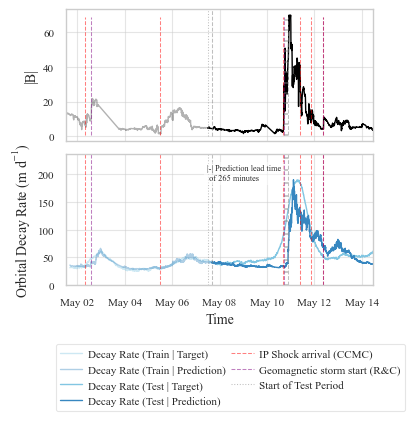

In [12]:
values_during_event = {}
for i, satellite in enumerate(satellites):
    if satellite not in scores_and_coef_dfs:
        print(f"No results for {satellite}, skipping...")
        continue

    io = ResultsIO(
        results_base_path=RESULTS_BASE_PATH,
        satellite=satellite,
        most_recent_timestamp=most_recent_timestamp,
        target=most_recent_grid_config['target']
    )
    results = io.read_results()

    top_scoring_lasso_feature = results[satellite]['no_val']['coefficients']['train'].sort_values(by='coef_abs', ascending=False).iloc[0]['feature']

    plot_results(io, icme_durations, best_lag=target_lags[i], col_to_plot=(top_scoring_lasso_feature, feature_to_physics_notation(top_scoring_lasso_feature)),
                 filepath=os.path.join(RESULTS_BASE_PATH, 'satellites', satellite, 'plots', f'predictions_{most_recent_timestamp}_{satellite}_results.png'), cme_catalogs_to_plot=[ 'L1_IPShock_arrivals_CCMC', 'L1_ICME_arrivals_RC'], show=satellite_configuration[satellite]['name'] == 'Swarm A')

# 5. Summarize feature importances

In [13]:
feats_all_sats = prepare_coefs_df(scores_and_coef_dfs)

low_alt_sats = [key for key in satellite_configuration.keys() if satellite_configuration[key]['altitude'] < 600]
grace_satellites = [key for key in satellite_configuration.keys() if 'GFO' in key]
swarm_ac_satellties = [key for key in satellite_configuration.keys() if 'SWMA' in key or 'SWMC' in key]
high_alt_sats = [sat for sat in satellites if sat not in low_alt_sats]

blacklist_idx = []

for sat_id, sat in enumerate(satellites):
    if scores_and_coef_dfs.get(sat) is None:
        if sat in low_alt_sats:
            low_alt_sats.remove(sat)
        if sat in high_alt_sats:
            high_alt_sats.remove(sat)
    else:
        r2 = scores_and_coef_dfs[sat]['no_val']['scores']['test']['R2']
        if r2 < 0.1:
            if sat in low_alt_sats:
                low_alt_sats.remove(sat)
            if sat in high_alt_sats:
                high_alt_sats.remove(sat)

    if sat_id in blacklist_idx:
        if sat in low_alt_sats:
            low_alt_sats.remove(sat)
        if sat in high_alt_sats:
            high_alt_sats.remove(sat)

unique_features = list(feats_all_sats['feature'].unique()) + ["Others"]
colors_by_feature = dict(zip(unique_features, sns.color_palette("tab20", len(unique_features))))

In [14]:
importance_text = {
    'lasso': 'Lasso',
    'shap': 'SHAP',
    'both': 'Combined SHAP and Lasso'
}
base_colors = get_base_colors_for_alphabetical_sorted_features(feats_all_sats)

for importance_kind in ['lasso', 'shap', 'both']:
    print(f"Processing importance kind: {importance_kind}")
    feats_low_alt = process_alt_feats(feats_all_sats, low_alt_sats, colors_by_feature, threshold=0.001, importance_kind=importance_kind)
    feats_high_alt = process_alt_feats(feats_all_sats, high_alt_sats, colors_by_feature, threshold=0.02, importance_kind=importance_kind)
    feats_grace = process_alt_feats(feats_all_sats, grace_satellites, colors_by_feature, threshold=0.001, importance_kind=importance_kind)
    feats_swarm_ac = process_alt_feats(feats_all_sats, swarm_ac_satellties, colors_by_feature, threshold=0.001, importance_kind=importance_kind)

    color = sns.color_palette("Blues", n_colors=2)[1]

    plot_lasso_importance_with_stacked_lagged_inputs_black_and_white(feats_low_alt, f'Satellites:\n{", ".join(list(map(lambda s: satellite_configuration[s]["name"], low_alt_sats)))}',
        filepath=os.path.join(RESULTS_BASE_PATH, 'summary', f'{most_recent_timestamp}_low_alt_importance_{importance_kind}_bw.png'), label=importance_text[importance_kind], color=color, xlim=0.4)

    plot_lasso_importance_with_stacked_lagged_inputs_black_and_white(feats_high_alt, 'Satellites:\n' + ', '.join(list(map(lambda s: satellite_configuration[s]["name"], high_alt_sats))),
        filepath=os.path.join(RESULTS_BASE_PATH, 'summary', f'{most_recent_timestamp}_high_alt_importance_{importance_kind}_bw.png'),
        label=importance_text[importance_kind], color=color, xlim=0.5)

    plot_lasso_importance_with_stacked_lagged_inputs_black_and_white(feats_grace, 'Satellites:\n' + ', '.join(list(map(lambda s: satellite_configuration[s]["name"], grace_satellites))),
        filepath=os.path.join(RESULTS_BASE_PATH, 'summary', f'{most_recent_timestamp}_grace_fo_importance_{importance_kind}_bw.png'),
        label=importance_text[importance_kind], color=color, xlim=0.5)

    plot_lasso_importance_with_stacked_lagged_inputs_black_and_white(feats_swarm_ac, 'Satellites:\n' + ', '.join( list(map(lambda s: satellite_configuration[s]["name"], swarm_ac_satellties))),
        filepath=os.path.join(RESULTS_BASE_PATH, 'summary', f'{most_recent_timestamp}_swarm_ac_importance_{importance_kind}_bw.png'),
        label=importance_text[importance_kind], color=color, xlim=0.5)

Processing importance kind: lasso
Processing importance kind: shap
Processing importance kind: both


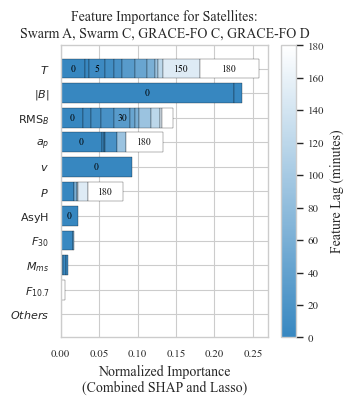

In [15]:
importance_kind = 'both'
feats_low_alt = process_alt_feats(feats_all_sats, low_alt_sats, colors_by_feature, threshold=0.001, importance_kind=importance_kind)
color = sns.color_palette("Blues", n_colors=2)[1]

plot_lasso_importance_with_stacked_lagged_inputs_black_and_white(feats_low_alt, f'Satellites:\n{", ".join(list(map(lambda s: satellite_configuration[s]["name"], low_alt_sats)))}',
    filepath=os.path.join(RESULTS_BASE_PATH, 'summary', f'{most_recent_timestamp}_low_alt_importance_{importance_kind}_bw.png'), label=importance_text[importance_kind], color=color, xlim=0.27, show=True)